In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('instagram_post.csv')

df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count
0,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,114,2,1,22,1639,2616,115,8
1,IG0000023,15,brand,8167,carousel,Photography,Home Feed,0,2025-02-26 10:00:00,2025-02-26,1946,52,96,264,29461,45796,103,6
2,IG0000024,15,brand,8167,image,Lifestyle,Profile,1,2025-03-20 19:00:00,2025-03-20,78,2,2,11,4093,6214,111,8
3,IG0000041,15,brand,8167,image,Comedy,External,1,2024-11-25 16:00:00,2024-11-25,332,9,13,44,7259,10099,142,10
4,IG0000045,15,brand,8167,image,Photography,External,0,2025-06-28 04:00:00,2025-06-28,796,17,36,120,11931,14927,141,8


In [ ]:
# DATA CLEANING

# Cek missing values
print("Missing Values:")
print(df.isnull().sum())

# Cek data duplikat
print("\nJumlah Duplikat:")
print(df.duplicated().sum())

Missing Values:
post_id               0
account_id            0
account_type          0
follower_count        0
media_type            0
content_category      0
traffic_source        0
has_call_to_action    0
post_datetime         0
post_date             0
likes                 0
comments              0
shares                0
saves                 0
reach                 0
impressions           0
caption_length        0
hashtags_count        0
total_interactions    0
month                 0
dtype: int64

Jumlah Duplikat:
0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   post_id             1599 non-null   object
 1   account_id          1599 non-null   int64 
 2   account_type        1599 non-null   object
 3   follower_count      1599 non-null   int64 
 4   media_type          1599 non-null   object
 5   content_category    1599 non-null   object
 6   traffic_source      1599 non-null   object
 7   has_call_to_action  1599 non-null   int64 
 8   post_datetime       1599 non-null   object
 9   post_date           1599 non-null   object
 10  likes               1599 non-null   int64 
 11  comments            1599 non-null   int64 
 12  shares              1599 non-null   int64 
 13  saves               1599 non-null   int64 
 14  reach               1599 non-null   int64 
 15  impressions         1599 non-null   int64 
 16  caption_length      1599

In [ ]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
df['post_date'] = pd.to_datetime(df['post_date'])

In [ ]:
df['total_interactions'] = (
    df['likes'] +
    df['comments'] +
    df['shares'] +
    df['saves']
)

In [ ]:
df['month'] = df['post_date'].dt.to_period('M')

In [ ]:
monthly_performance = df.groupby('month').agg(
    post_count=('post_id', 'count'),
    average_reach=('reach', 'mean'),
    average_interactions=('total_interactions', 'mean')
).reset_index()

monthly_performance

,month,post_count,average_reach,average_interactions
0,2024-11,54,6106.092593,312.611111
1,2024-12,126,6094.968254,367.611111
2,2025-01,137,6266.058394,312.905109
3,2025-02,130,6273.830769,303.946154
4,2025-03,130,6790.261538,415.361538
5,2025-04,128,6798.781250,402.695312
6,2025-05,146,6501.897260,352.253425
7,2025-06,147,6390.380952,372.197279
8,2025-07,153,6546.705882,385.614379
9,2025-08,128,6650.140625,343.195312


In [ ]:
media_performance = df.groupby('media_type').agg(
    post_count=('post_id', 'count'),
    average_reach=('reach', 'mean'),
    average_interactions=('total_interactions', 'mean')
).reset_index()

media_performance

,media_type,post_count,average_reach,average_interactions
0,carousel,549,6673.340619,379.258652
1,image,603,6480.018242,372.991708
2,reel,447,6333.413870,332.859060


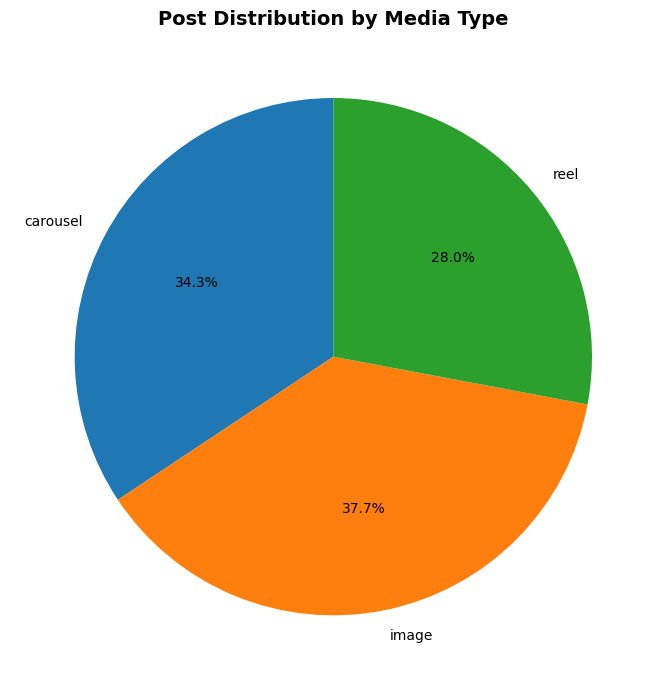

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(
    media_performance['post_count'],
    labels=media_performance['media_type'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Post Distribution by Media Type',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
category_performance = df.groupby('content_category').agg(
    post_count=('post_id', 'count'),
    average_reach=('reach', 'mean'),
    average_interactions=('total_interactions', 'mean')
).sort_values('average_interactions', ascending=False).reset_index()

category_performance

,content_category,post_count,average_reach,average_interactions
0,Photography,182,7063.049451,398.510989
1,Music,146,6447.260274,397.273973
2,Technology,155,6584.174194,393.812903
3,Fashion,141,6282.234043,373.822695
4,Lifestyle,155,6483.458065,362.690323
5,Travel,168,6792.547619,358.886905
6,Fitness,148,6153.114865,344.378378
7,Food,188,6503.691489,342.265957
8,Beauty,161,6292.242236,336.211180
9,Comedy,155,6300.283871,333.419355


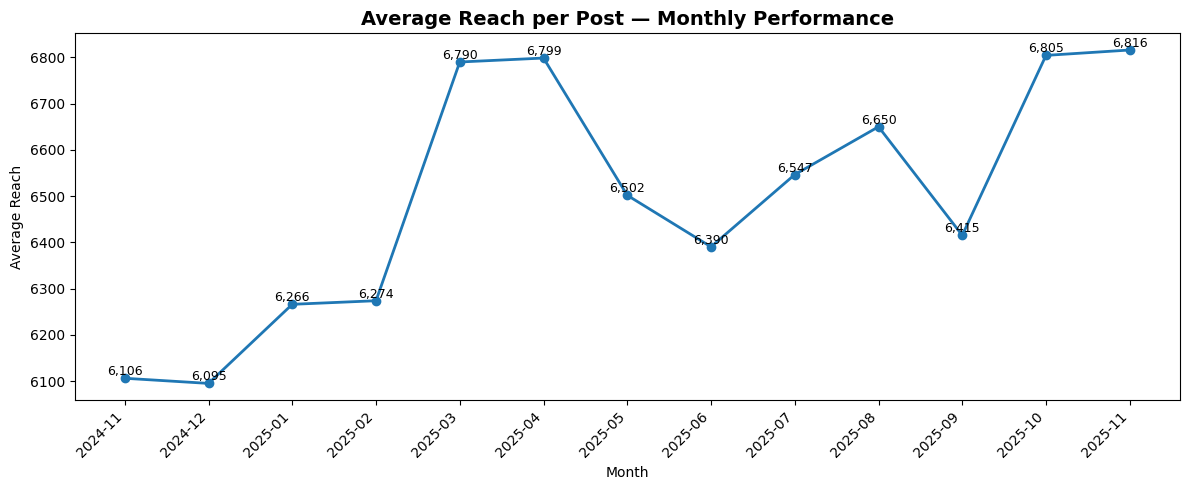

In [ ]:
plt.figure(figsize=(12, 5))

# Buat label bulan yang lebih rapi
monthly_plot = monthly_performance.copy()
monthly_plot['month_label'] = monthly_plot['month'].astype(str)

plt.plot(
    monthly_plot['month_label'],
    monthly_plot['average_reach'],
    marker='o',
    linewidth=2
)

# Menampilkan nilai di atas titik
for x, y in zip(
    monthly_plot['month_label'],
    monthly_plot['average_reach']
):
    plt.text(
        x, y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Judul
plt.title(
    'Average Reach per Post — Monthly Performance',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Average Reach')

# Rapikan nama bulan
plt.xticks(
    rotation=45,
    ha='right'
)

# Hilangkan kotak/grid
plt.grid(False)

plt.tight_layout()
plt.show()